In [ ]:
!pip install pandas scikit-learn matplotlib seaborn nltk

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import nltk
from nltk.corpus import stopwords
import string

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
#Loading the Dataset

from google.colab import files
files.upload()

import pandas as pd

df = pd.read_csv("/content/fake_job_postings.csv")
df.head()

Saving fake_job_postings.csv to fake_job_postings.csv


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [ ]:
#Cleaning Text Data

df = df[['description', 'fraudulent']].dropna()

def clean_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

df['clean_desc'] = df['description'].apply(clean_text)

In [ ]:
#Split Data into Train and Test Sets

X = df['clean_desc']
y = df['fraudulent']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#Convert Text into Numbers

tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
#Train the model

model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

LogisticRegression()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Predict on test set
y_pred = model.predict(X_test_tfidf)

# Print metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

# Full classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.9661633109619687
Precision: 0.9841269841269841
Recall: 0.34065934065934067
F1 Score: 0.5061224489795918

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3394
           1       0.98      0.34      0.51       182

    accuracy                           0.97      3576
   macro avg       0.97      0.67      0.74      3576
weighted avg       0.97      0.97      0.96      3576



              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3394
           1       0.98      0.34      0.51       182

    accuracy                           0.97      3576
   macro avg       0.97      0.67      0.74      3576
weighted avg       0.97      0.97      0.96      3576



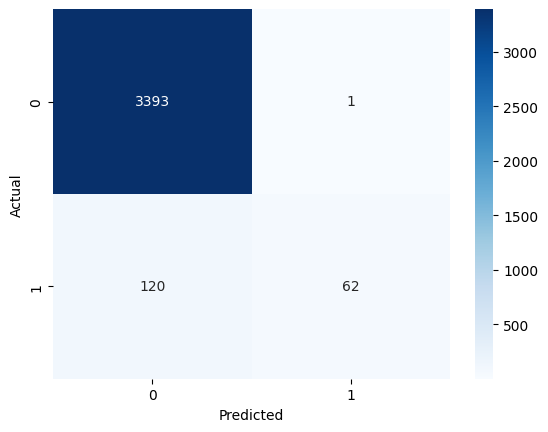

In [ ]:
#Evaluate the model

y_pred = model.predict(X_test_tfidf)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
def predict_fake_job(description):
    desc_clean = clean_text(description)
    desc_vec = tfidf.transform([desc_clean])
    pred = model.predict(desc_vec)[0]
    return "Fake" if pred==1 else "Real"

predict_fake_job("Looking for software engineer with 10 years experience in Python...")


'Real'

In [ ]:
import numpy as np

feature_names = tfidf.get_feature_names_out()
coefficients = model.coef_[0]
top_features = np.argsort(coefficients)[-20:]

print("Top words indicating fake jobs:")
for i in top_features:
    print(feature_names[i], round(coefficients[i], 3))


Top words indicating fake jobs:
seeking 1.731
oil 1.733
optical 1.768
call 1.814
per 1.822
weather 1.875
wages 1.93
clerk 1.936
administrative 1.939
work 1.953
type 1.964
petroleum 1.971
subsea 2.038
perform 2.06
gas 2.218
earn 2.255
engineering 2.303
skills 2.423
entry 2.863
money 3.373


In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 68.8 MB/s eta 0:00:00


In [ ]:
#@title Convert ipynb to HTML in Colab
# Upload ipynb
from google.colab import files
f = files.upload()

# Convert ipynb to html
import subprocess
file0 = list(f.keys())[0]
_ = subprocess.run(["pip", "install", "nbconvert"])
_ = subprocess.run(["jupyter", "nbconvert", file0, "--to", "html"])

# download the html
files.download(file0[:-5]+"html")